INFO:root:creating a Pool of 4 workers
/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/tmp/ipykernel_1702606/2430659130.py:52: RuntimeWarning: divide by zero encountered in log2
  log2oe = np.log2(oe)
/tmp/ipykernel_1702606/2430659130.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → DL-20240828-LCHCSeq-K562SpeckledTAG-NegDMSO120mPD-DpnII-R1-T1__hg38.chr11.250kb.CraneHeatmap_log2OE.png


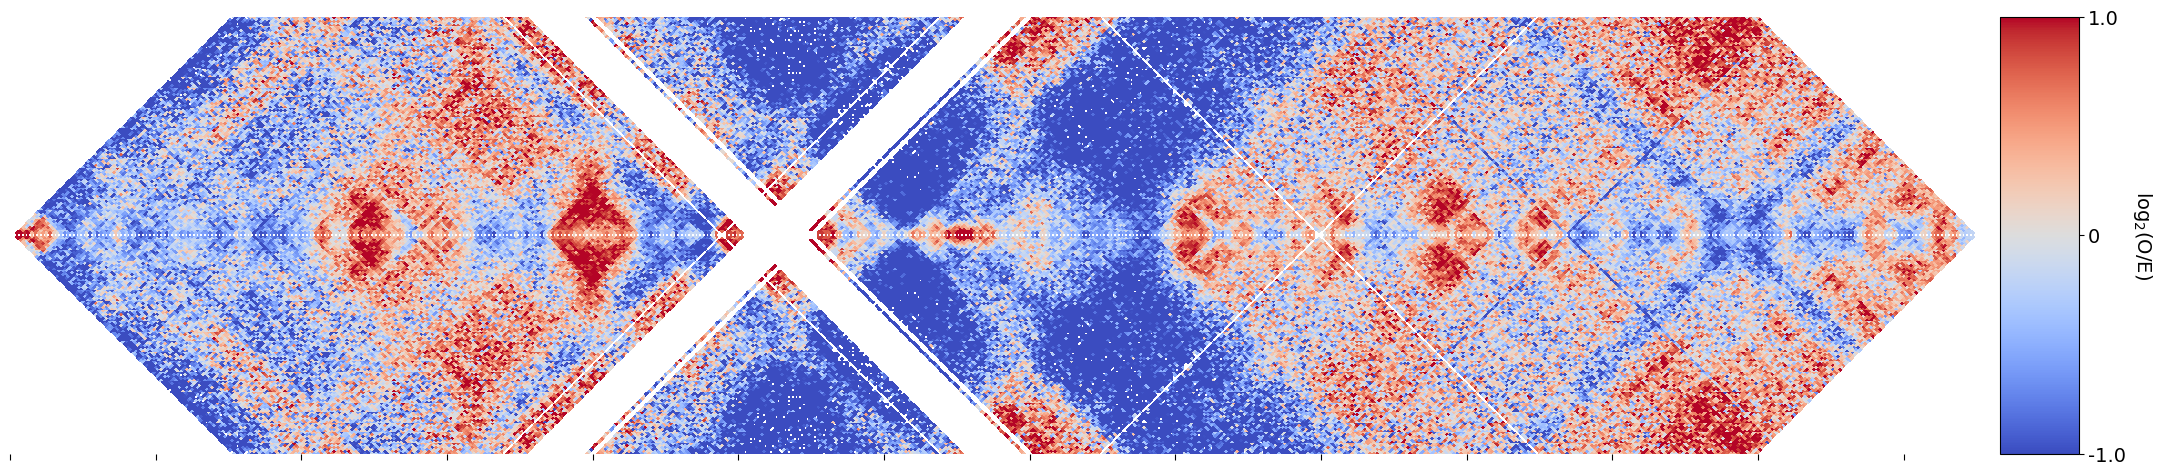

In [2]:
########################### NT-DpnII treatment ###############

import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
import bioframe
import os
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import itertools

######### CONFIG 
resolution  = 250_000
data_dir    = '/abyss/dlafonta/LC-HiC/distiller_runs/20241022_LC-Hi-C_SPdTAG_HS_TD_remap/coolers_library/'
cool_file   = 'DL-20240828-LCHCSeq-K562SpeckledTAG-NegDMSO120mPD-DpnII-R1-T1__hg38.hg38.exclude1kb.1000.mcool'
region      = 'chr11'          # full chromosome
vmin, vmax  = -1.0, 1.0        # log2 O/E colour limits
cmap        = 'coolwarm'

######### LOAD COOLER 
clr = cooler.Cooler(f'{data_dir}/{cool_file}::/resolutions/{resolution}')

######### COMPUTE EXPECTED (whole-genome arms table, then trim to chr)

hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens       = bioframe.fetch_centromeres('hg38')
hg38_arms       = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
hg38_arms       = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=4, ignore_diags=0)

# Keep only rows for our chromosome
expected_chr = expected[expected['region1'].str.contains(region) if hasattr(expected['region1'], 'str') else expected['region1'] == region].copy()
expected_vals = np.array(expected_chr['balanced.avg.smoothed'].values, dtype=np.float64)

########## FETCH OBSERVED MATRIX
obs = np.array(clr.matrix(balance=True).fetch(region), dtype=np.float64)

########## BUILD log2(O/E) MATRIX
n = obs.shape[0]
oe = np.full_like(obs, np.nan)

for i in range(n):
    for j in range(i, n):
        d = j - i
        if d < len(expected_vals) and expected_vals[d] > 0:
            v = obs[i, j] / expected_vals[d]
            oe[i, j] = v
            oe[j, i] = v

log2oe = np.log2(oe)
log2oe[~np.isfinite(log2oe)] = np.nan   # Inf / -Inf → NaN

######### 45-DEGREE ROTATION HELPER 
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, flip_y=False, **kwargs):
    n = matrix_c.shape[0]
    start_pos = [start + resolution * i for i in range(n + 1)]
    t = np.array([[1, 0.5], [-1, 0.5]])
    coords = np.array([(i[1], i[0])
                       for i in itertools.product(start_pos[::-1], start_pos)])
    mat = np.dot(coords, t)
    x = mat[:, 1].reshape(n + 1, n + 1)
    y = mat[:, 0].reshape(n + 1, n + 1)
    if flip_y:
        y = -y
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), **kwargs)
    im.set_rasterized(True)
    return im

########## PLOT 
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

f, ax = plt.subplots(figsize=(20, 8))

im  = pcolormesh_45deg(ax, log2oe, start=0, resolution=resolution,
                       flip_y=False, norm=norm, cmap=cmap)
im2 = pcolormesh_45deg(ax, log2oe, start=0, resolution=resolution,
                       flip_y=True,  norm=norm, cmap=cmap)

ax.set_ylim(-30_000_000, 30_000_000)
ax.set_aspect(0.5)

# Hide all axes decorations (same as original)
tick_positions = np.arange(0, clr.chromsizes[region], 10_000_000)
ax.set_xticks(tick_positions)
ax.set_xticklabels([])
ax.tick_params(axis='x', length=4, width=0.8, direction='out')
ax.spines['bottom'].set_visible(True)

ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar — same inset placement as original
cax = inset_axes(ax,
                 width="4%", height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.05, 0., 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('log$_2$(O/E)', rotation=270, labelpad=20, fontsize=14)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()

out_name = f'{cool_file[:-27]}.{region}.{resolution//1000}kb.CraneHeatmap_log2OE.png'
plt.savefig(out_name, bbox_inches='tight', transparent=True, dpi=150)
print(f"Saved → {out_name}")
plt.show()